# 01 · Preprocesamiento Fase 1

## Predicción de inundaciones en Antioquia

Este cuaderno resume y documenta la revisión técnica del dataset final de Fase 1 (estructura municipio-fecha) antes del entrenamiento del baseline de clasificación.

- Problema: clasificación binaria (`flood_next_24h`)
- Horizonte: 24 horas
- Alcance: Fase 1 tabular (sin arquitecturas profundas)
- Construcción de dataset: ya realizada con `build_phase1_dataset.py`

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use('default')
pd.set_option('display.max_columns', 120)
print('Librerías cargadas')

Librerías cargadas


## Carga de datos

Se carga el dataset procesado de Fase 1 desde rutas locales o de Colab para facilitar reproducibilidad.

In [2]:
def first_existing_path(candidates):
    for p in candidates:
        path = Path(p)
        if path.exists():
            return path
    return None

dataset_candidates = [
    'processed/fase1/phase1_dataset_municipio_fecha.csv',
    '../processed/fase1/phase1_dataset_municipio_fecha.csv',
    '/content/processed/fase1/phase1_dataset_municipio_fecha.csv',
    '/content/phase1_dataset_municipio_fecha.csv'
]
metadata_candidates = [
    'processed/fase1/phase1_dataset_metadata.json',
    '../processed/fase1/phase1_dataset_metadata.json',
    '/content/processed/fase1/phase1_dataset_metadata.json',
    '/content/phase1_dataset_metadata.json'
]

dataset_path = first_existing_path(dataset_candidates)
if dataset_path is None:
    raise FileNotFoundError('No se encontró phase1_dataset_municipio_fecha.csv')

df = pd.read_csv(dataset_path)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

metadata_path = first_existing_path(metadata_candidates)
metadata = None
if metadata_path is not None:
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)

print('Dataset:', dataset_path)
print('Metadata:', metadata_path if metadata_path else 'no encontrada')

Dataset: ..\processed\fase1\phase1_dataset_municipio_fecha.csv
Metadata: ..\processed\fase1\phase1_dataset_metadata.json


## Inspección general

Primero verificamos forma, tipos de columna, muestra de registros, número de municipios y rango temporal.

In [3]:
TARGET_COL = 'flood_next_24h'
if TARGET_COL not in df.columns:
    raise ValueError('No existe flood_next_24h')

print('Shape:', df.shape)
print('\nTipos de columnas:')
print(df.dtypes)
display(Markdown('**Primeras filas**'))
display(df.head())
display(Markdown('**Últimas filas**'))
display(df.tail())

muni_col = 'municipio_key' if 'municipio_key' in df.columns else ('municipio_name' if 'municipio_name' in df.columns else None)
if muni_col:
    print('Municipios únicos:', df[muni_col].nunique(dropna=True))
if 'date' in df.columns:
    print('Rango de fechas:', df['date'].min(), '->', df['date'].max())

Shape: (341787, 52)

Tipos de columnas:
municipio_key                                  str
date                                datetime64[us]
municipio_name                                 str
stations_in_municipio                      float64
latitud_raw                                float64
longitud_raw                               float64
altitud_raw                                float64
meteo_obs_count_24h                        float64
meteo_station_count_24h                    float64
meteo_temp_mean_24h                        float64
meteo_temp_max_24h                         float64
meteo_rh_mean_24h                          float64
meteo_rh_max_24h                           float64
meteo_wind_mean_24h                        float64
meteo_wind_max_24h                         float64
precip_mm_24h_sum                          float64
precip_mm_24h_max                          float64
precip_obs_count_24h                       float64
precip_station_count_24h                  

**Primeras filas**

,municipio_key,date,municipio_name,stations_in_municipio,latitud_raw,longitud_raw,altitud_raw,meteo_obs_count_24h,meteo_station_count_24h,meteo_temp_mean_24h,meteo_temp_max_24h,meteo_rh_mean_24h,meteo_rh_max_24h,meteo_wind_mean_24h,meteo_wind_max_24h,precip_mm_24h_sum,precip_mm_24h_max,precip_obs_count_24h,precip_station_count_24h,precip_mm_48h_sum,precip_mm_72h_sum,flood_next_24h,year,month,day,day_of_year,day_of_week,is_weekend,stations_in_municipio_missing,latitud_raw_missing,longitud_raw_missing,altitud_raw_missing,meteo_obs_count_24h_missing,meteo_station_count_24h_missing,meteo_temp_mean_24h_missing,meteo_temp_max_24h_missing,meteo_rh_mean_24h_missing,meteo_rh_max_24h_missing,meteo_wind_mean_24h_missing,meteo_wind_max_24h_missing,precip_mm_24h_sum_missing,precip_mm_24h_max_missing,precip_obs_count_24h_missing,precip_station_count_24h_missing,precip_mm_48h_sum_missing,precip_mm_72h_sum_missing,year_missing,month_missing,day_missing,day_of_year_missing,day_of_week_missing,is_weekend_missing
0,abejorral,2018-01-01,Abejorral,7.0,5.828512,-75.452956,81.811429,24.0,1.0,24.175000,28.8,70.916667,97.0,3.287500,9.5,1.0,0.3,144.0,1.0,5.2,9.2,0,2018,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0
1,abejorral,2018-01-02,Abejorral,7.0,5.828512,-75.452956,81.811429,24.0,1.0,24.270833,29.0,75.291667,100.0,2.379167,4.0,1.0,0.3,144.0,1.0,5.2,9.2,0,2018,1,2,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0
2,abejorral,2018-01-03,Abejorral,7.0,5.828512,-75.452956,81.811429,24.0,1.0,25.400000,29.7,63.375000,81.0,2.825000,5.5,1.0,0.3,144.0,1.0,5.2,9.2,0,2018,1,3,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0
3,abejorral,2018-01-04,Abejorral,7.0,5.828512,-75.452956,81.811429,24.0,1.0,25.083333,30.4,68.291667,98.0,3.795833,7.4,1.0,0.3,144.0,1.0,5.2,9.2,0,2018,1,4,4,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0
4,abejorral,2018-01-05,Abejorral,7.0,5.828512,-75.452956,81.811429,24.0,1.0,24.437500,29.8,73.083333,98.0,3.200000,6.4,1.0,0.3,144.0,1.0,5.2,9.2,0,2018,1,5,5,4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0


**Últimas filas**

,municipio_key,date,municipio_name,stations_in_municipio,latitud_raw,longitud_raw,altitud_raw,meteo_obs_count_24h,meteo_station_count_24h,meteo_temp_mean_24h,meteo_temp_max_24h,meteo_rh_mean_24h,meteo_rh_max_24h,meteo_wind_mean_24h,meteo_wind_max_24h,precip_mm_24h_sum,precip_mm_24h_max,precip_obs_count_24h,precip_station_count_24h,precip_mm_48h_sum,precip_mm_72h_sum,flood_next_24h,year,month,day,day_of_year,day_of_week,is_weekend,stations_in_municipio_missing,latitud_raw_missing,longitud_raw_missing,altitud_raw_missing,meteo_obs_count_24h_missing,meteo_station_count_24h_missing,meteo_temp_mean_24h_missing,meteo_temp_max_24h_missing,meteo_rh_mean_24h_missing,meteo_rh_max_24h_missing,meteo_wind_mean_24h_missing,meteo_wind_max_24h_missing,precip_mm_24h_sum_missing,precip_mm_24h_max_missing,precip_obs_count_24h_missing,precip_station_count_24h_missing,precip_mm_48h_sum_missing,precip_mm_72h_sum_missing,year_missing,month_missing,day_missing,day_of_year_missing,day_of_week_missing,is_weekend_missing
341782,zaragoza,2024-12-27,Zaragoza,14.0,7.4519,-74.844562,207.714286,24.0,1.0,25.762500,31.2,88.583333,100.0,4.945833,14.4,1.0,0.3,144.0,1.0,5.2,9.2,0,2024,12,27,362,4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0
341783,zaragoza,2024-12-28,Zaragoza,14.0,7.4519,-74.844562,207.714286,24.0,1.0,25.337500,30.9,89.708333,100.0,5.000000,12.9,1.0,0.3,144.0,1.0,5.2,9.2,0,2024,12,28,363,5,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0
341784,zaragoza,2024-12-29,Zaragoza,14.0,7.4519,-74.844562,207.714286,24.0,1.0,25.529167,30.1,87.541667,100.0,4.316667,10.4,1.0,0.3,144.0,1.0,5.2,9.2,0,2024,12,29,364,6,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0
341785,zaragoza,2024-12-30,Zaragoza,14.0,7.4519,-74.844562,207.714286,24.0,1.0,25.020833,28.9,89.750000,100.0,4.304167,7.5,1.0,0.3,144.0,1.0,5.2,9.2,0,2024,12,30,365,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0
341786,zaragoza,2024-12-31,Zaragoza,14.0,7.4519,-74.844562,207.714286,24.0,1.0,25.316667,30.0,87.458333,100.0,4.650000,8.8,1.0,0.3,144.0,1.0,5.2,9.2,0,2024,12,31,366,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0


Municipios únicos: 133
Rango de fechas: 2018-01-01 00:00:00 -> 2024-12-31 00:00:00


## Calidad de datos

Se evalúan nulos, duplicados, columnas con varianza casi nula y consistencia de la variable objetivo.

In [4]:
nulls = df.isna().sum().sort_values(ascending=False)
null_pct = (nulls / len(df) * 100).round(3)
quality = pd.DataFrame({'null_count': nulls, 'null_pct': null_pct})
display(quality)

numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
near_zero_var = []
for c in numeric_cols:
    s = df[c].dropna()
    if s.empty or s.nunique() <= 1 or float(s.var()) < 1e-10:
        near_zero_var.append(c)

print('Duplicados totales:', int(df.duplicated().sum()))
if 'municipio_key' in df.columns and 'date' in df.columns:
    print('Duplicados (municipio_key, date):', int(df.duplicated(subset=['municipio_key','date']).sum()))
print('Varianza casi nula:', near_zero_var)

y = pd.to_numeric(df[TARGET_COL], errors='coerce')
print('Target nulos:', int(y.isna().sum()))
print('Target únicos:', sorted(y.dropna().unique().tolist()))

,null_count,null_pct
municipio_key,0,0.0
date,0,0.0
municipio_name,0,0.0
stations_in_municipio,0,0.0
latitud_raw,0,0.0
longitud_raw,0,0.0
altitud_raw,0,0.0
meteo_obs_count_24h,0,0.0
meteo_station_count_24h,0,0.0
meteo_temp_mean_24h,0,0.0


Duplicados totales: 1706
Duplicados (municipio_key, date): 1706
Varianza casi nula: ['precip_station_count_24h', 'year_missing', 'month_missing', 'day_missing', 'day_of_year_missing', 'day_of_week_missing', 'is_weekend_missing']
Target nulos: 0
Target únicos: [0, 1]


## EDA (matplotlib)

Exploración descriptiva de la variable objetivo, variables numéricas principales, correlaciones y cobertura temporal.

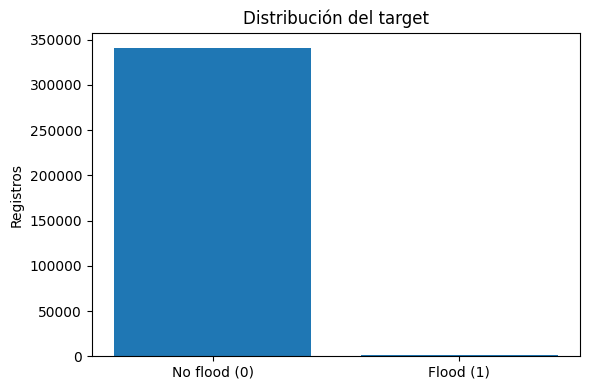

Tasa positiva: 0.0038 (0.38%)


In [5]:
y = pd.to_numeric(df[TARGET_COL], errors='coerce').fillna(0).astype(int)
target_counts = y.value_counts().sort_index()
target_rate = float(y.mean())

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['No flood (0)','Flood (1)'], [target_counts.get(0,0), target_counts.get(1,0)])
ax.set_title('Distribución del target')
ax.set_ylabel('Registros')
plt.tight_layout()
plt.show()
print(f'Tasa positiva: {target_rate:.4f} ({target_rate*100:.2f}%)')

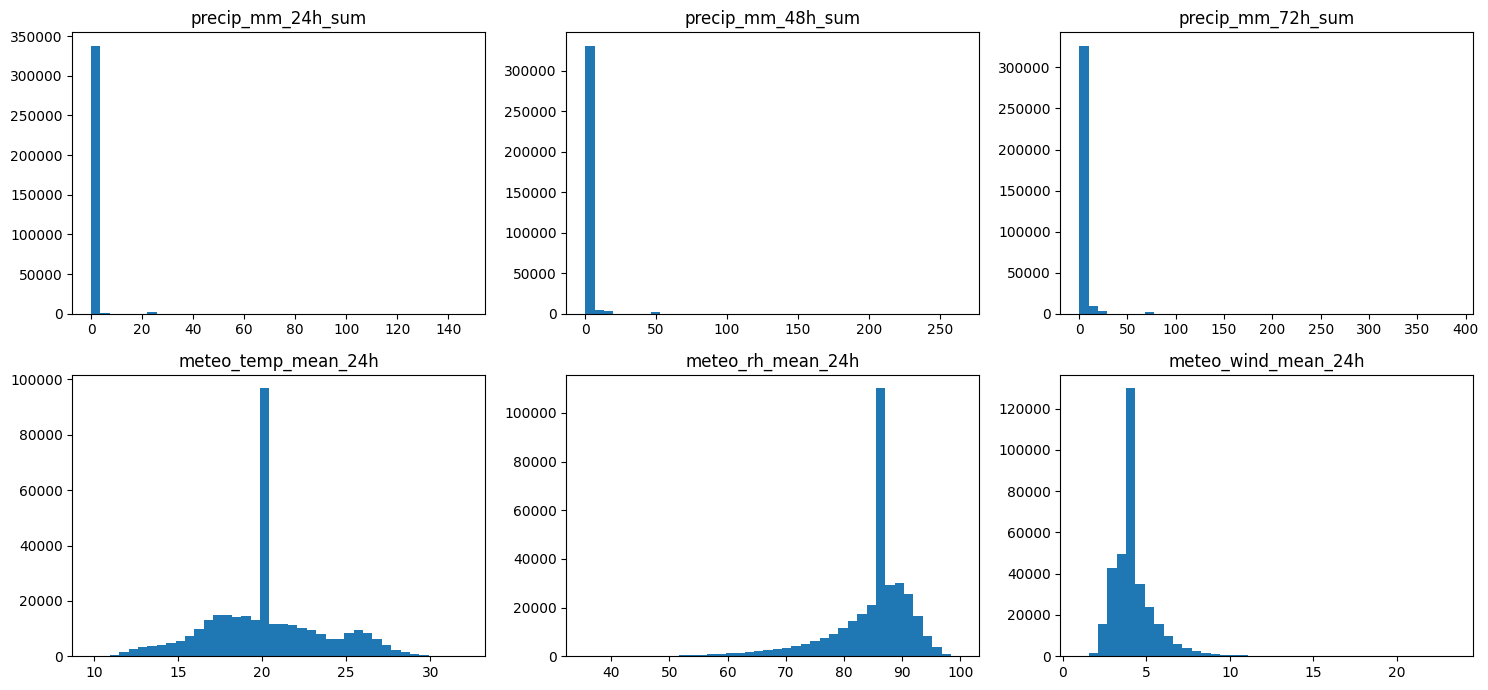

In [6]:
preferred = ['precip_mm_24h_sum','precip_mm_48h_sum','precip_mm_72h_sum','meteo_temp_mean_24h','meteo_rh_mean_24h','meteo_wind_mean_24h','river_level_mean_24h']
hist_cols = [c for c in preferred if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
if not hist_cols:
    hist_cols = [c for c in numeric_cols if c != TARGET_COL][:8]

n = len(hist_cols)
ncols = 3
nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = np.array(axes).reshape(-1)
for i, c in enumerate(hist_cols):
    axes[i].hist(pd.to_numeric(df[c], errors='coerce').dropna(), bins=40)
    axes[i].set_title(c)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

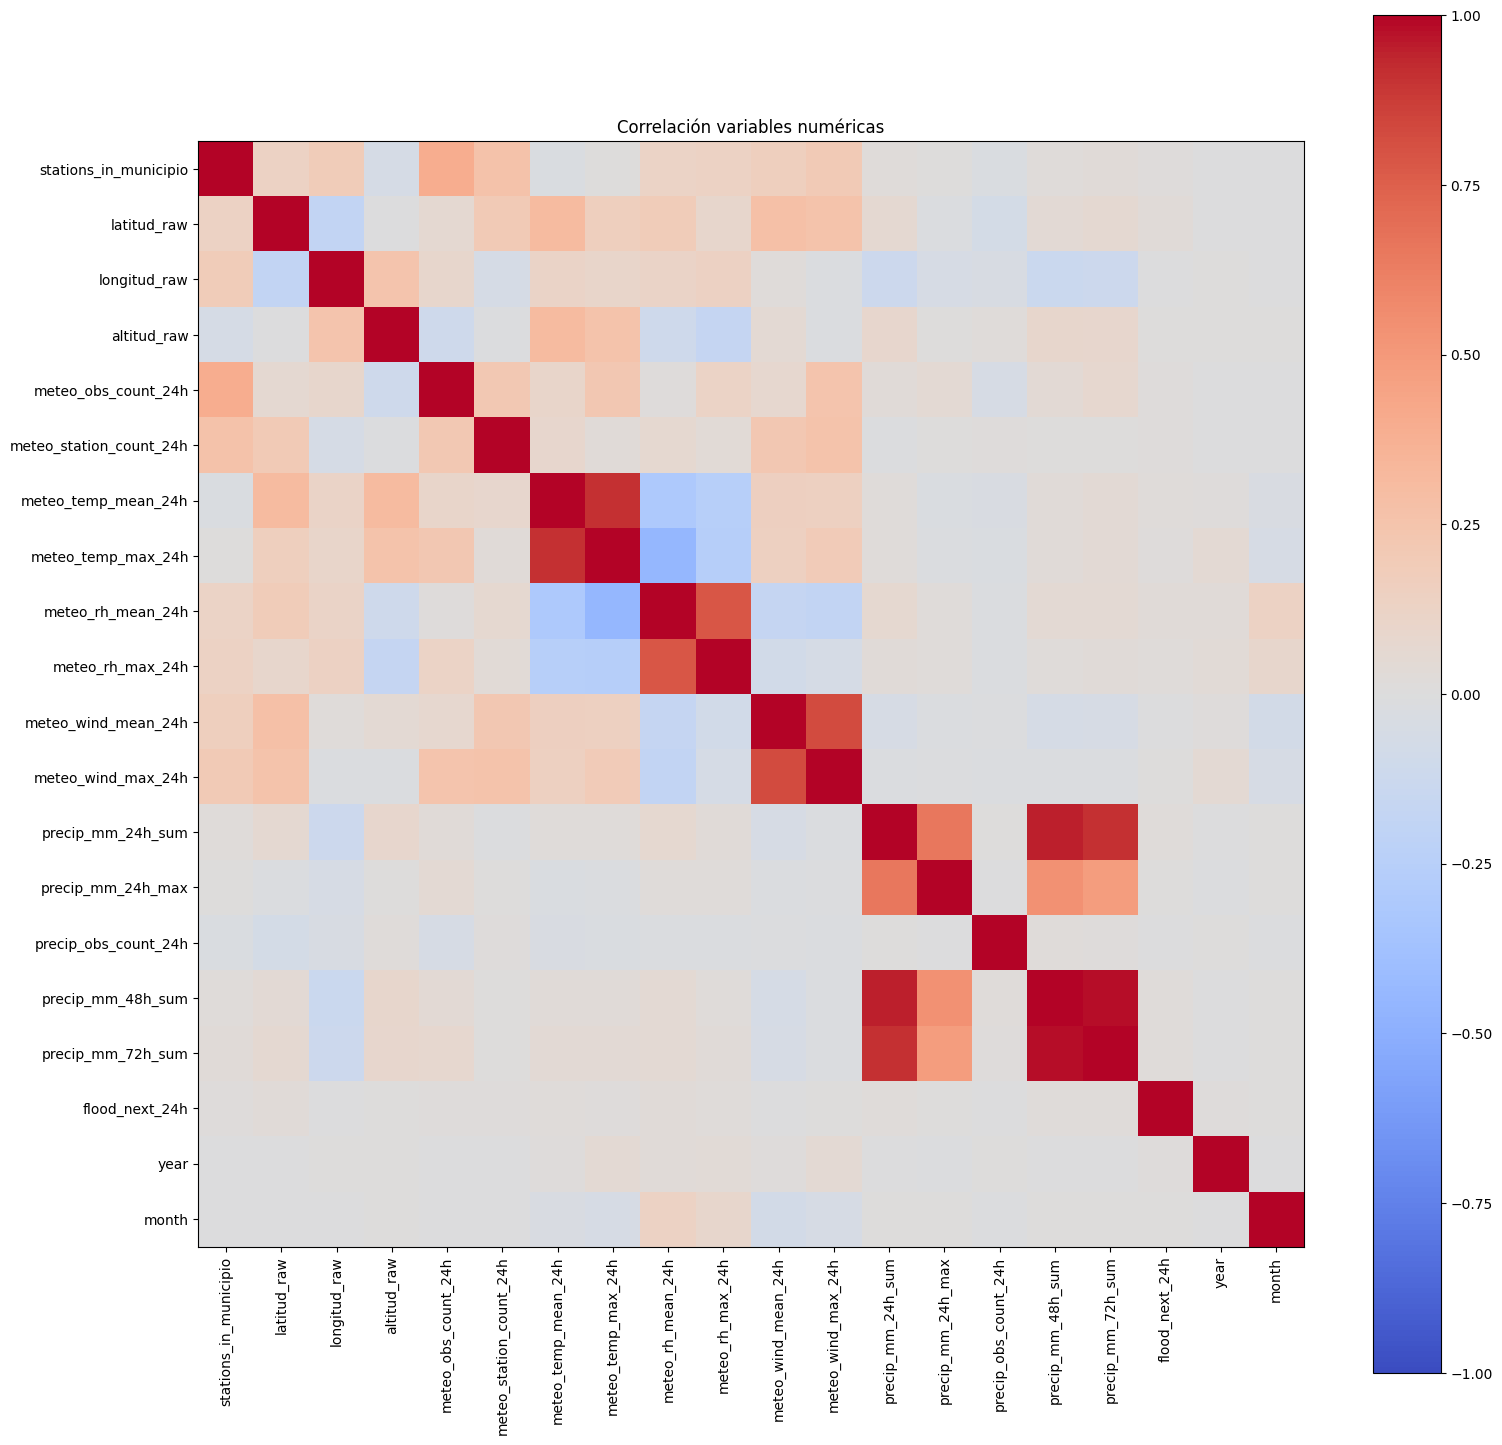

In [7]:
corr_cols = [c for c in numeric_cols if df[c].nunique(dropna=True) > 1]
corr_cols = corr_cols[:20] if len(corr_cols) > 20 else corr_cols
corr = df[corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(0.6*len(corr_cols)+4, 0.6*len(corr_cols)+3))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90)
ax.set_yticklabels(corr_cols)
ax.set_title('Correlación variables numéricas')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

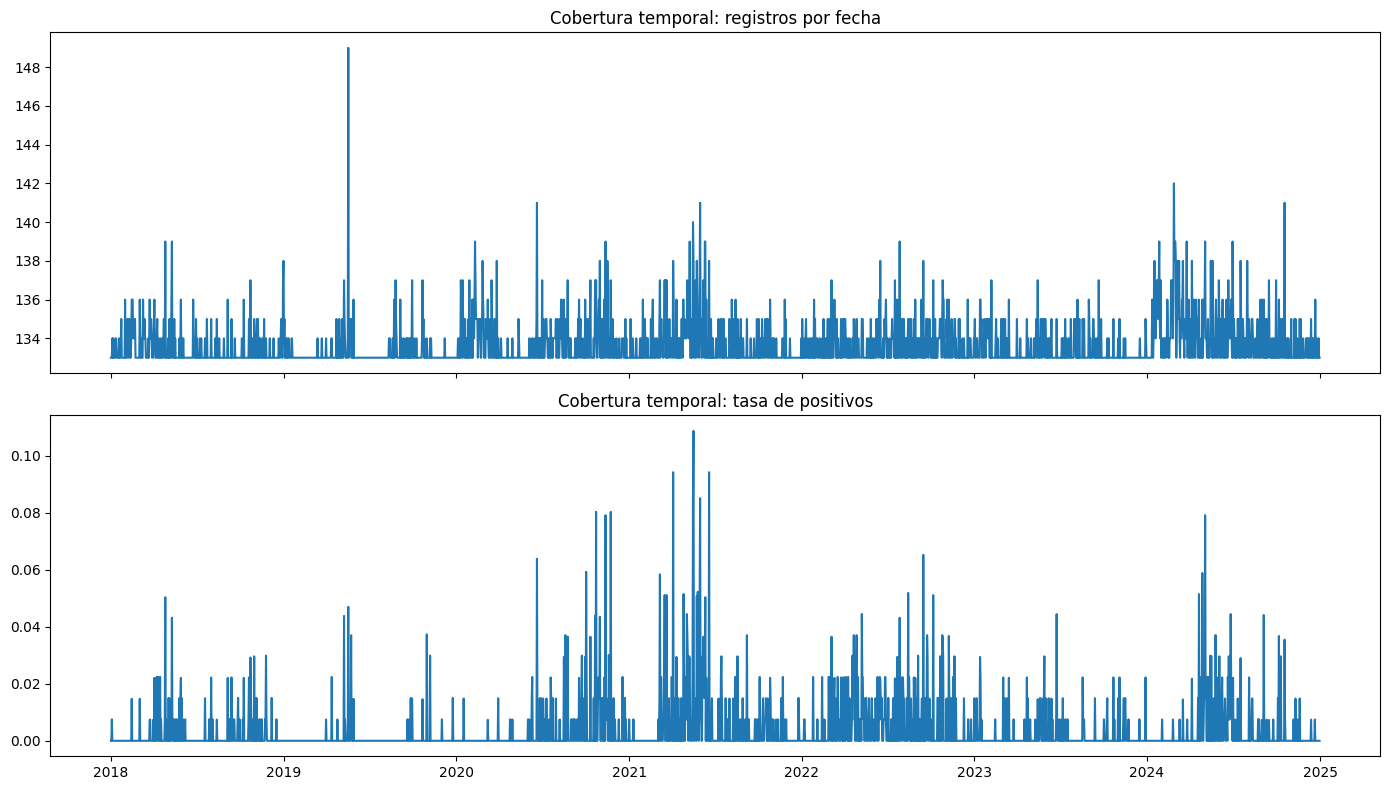

In [8]:
if 'date' in df.columns:
    temp = df.dropna(subset=['date']).copy()
    temp['_day'] = temp['date'].dt.floor('D')
    daily_count = temp.groupby('_day').size().sort_index()
    daily_pos = temp.groupby('_day')[TARGET_COL].mean().sort_index()

    fig, axes = plt.subplots(2, 1, figsize=(14,8), sharex=True)
    axes[0].plot(daily_count.index, daily_count.values)
    axes[0].set_title('Cobertura temporal: registros por fecha')
    axes[1].plot(daily_pos.index, daily_pos.values)
    axes[1].set_title('Cobertura temporal: tasa de positivos')
    plt.tight_layout()
    plt.show()

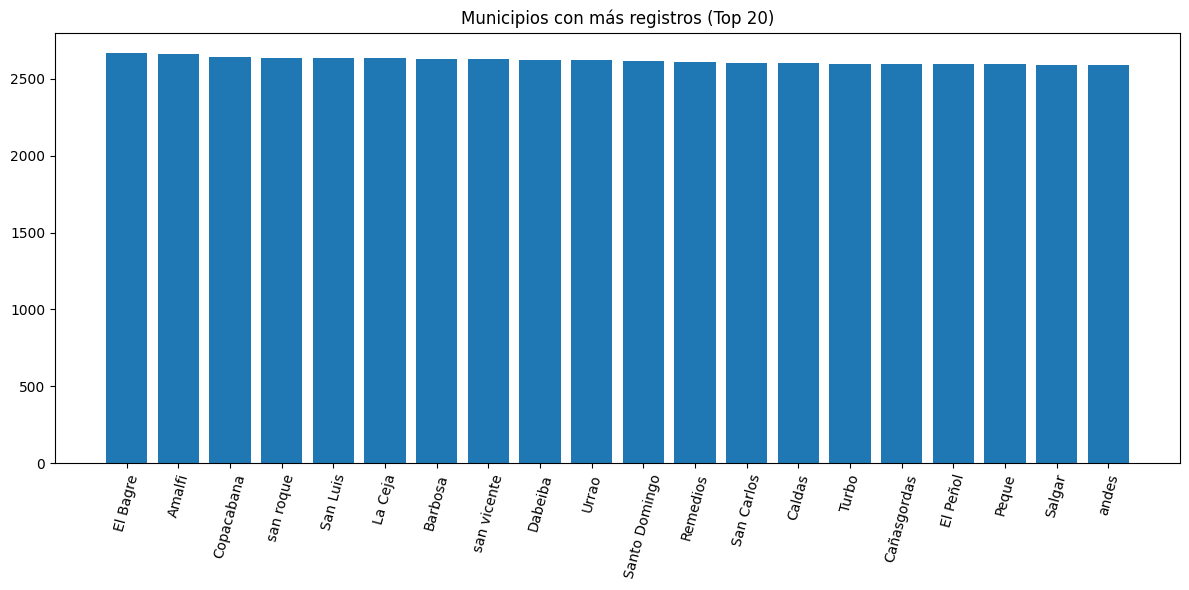

In [9]:
muni_col = 'municipio_name' if 'municipio_name' in df.columns else ('municipio_key' if 'municipio_key' in df.columns else None)
if muni_col is not None:
    top = df[muni_col].astype(str).value_counts().head(20)
    fig, ax = plt.subplots(figsize=(12,6))
    ax.bar(top.index, top.values)
    ax.set_title('Municipios con más registros (Top 20)')
    ax.tick_params(axis='x', rotation=75)
    plt.tight_layout()
    plt.show()

C:\Users\Pc\AppData\Local\Temp\ipykernel_36696\1276110660.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(arr, labels=box_cols, showfliers=True)


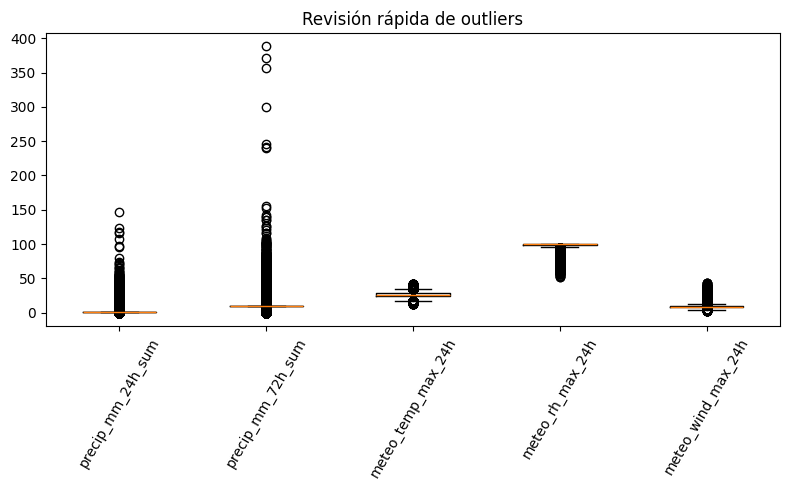

In [10]:
box_cols_pref = ['precip_mm_24h_sum','precip_mm_72h_sum','meteo_temp_max_24h','meteo_rh_max_24h','meteo_wind_max_24h','river_level_max_24h']
box_cols = [c for c in box_cols_pref if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
if not box_cols:
    box_cols = [c for c in numeric_cols if c != TARGET_COL][:6]

arr = [pd.to_numeric(df[c], errors='coerce').dropna().values for c in box_cols]
fig, ax = plt.subplots(figsize=(max(8, 1.6*len(box_cols)), 5))
ax.boxplot(arr, labels=box_cols, showfliers=True)
ax.set_title('Revisión rápida de outliers')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

## Interpretación breve

- El dataset está alineado con el objetivo de clasificación binaria de Fase 1.
- El nivel de desbalance del target debe considerarse explícitamente en evaluación y selección de umbral.
- Se observan outliers en variables hidrometeorológicas, lo cual es esperable y manejable con preprocesamiento robusto.
- La estructura general es apta para continuar al baseline MLP.

## Conclusiones del preprocesamiento

La revisión confirma que el dataset final posee trazabilidad, cobertura temporal útil y calidad suficiente para iniciar entrenamiento en Fase 1.

## Conexión con el baseline MLP

El siguiente paso es ejecutar `notebooks/02_mlp_baseline_fase1.ipynb` para split temporal, escalado, entrenamiento (logística + MLP) y análisis de métricas y predicciones.